In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE


In [3]:
df = pd.read_csv('../preprocessing/credit_risk_encoded.csv')

df

,customer_id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
0,CUST_00001,21,9600,5.0,1000,11.14,0,0.10,2,0,...,0,0,1,0,0,0,0,0,1,0
1,CUST_00002,25,9600,1.0,5500,12.87,1,0.57,3,1,...,0,0,0,1,0,0,0,0,1,0
2,CUST_00003,23,65500,4.0,35000,15.23,1,0.53,2,0,...,0,0,0,1,0,0,0,0,1,0
3,CUST_00004,24,54400,8.0,35000,14.27,1,0.55,4,0,...,0,0,0,1,0,0,0,0,0,1
4,CUST_00005,21,9900,2.0,2500,7.14,1,0.25,2,0,...,1,1,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32569,CUST_32570,57,53000,1.0,5800,13.16,0,0.11,30,1,...,0,0,0,1,0,0,0,0,1,0
32570,CUST_32571,54,120000,4.0,17625,7.49,0,0.15,19,1,...,0,1,0,0,0,0,0,0,1,0
32571,CUST_32572,65,76000,3.0,35000,10.99,1,0.46,28,0,...,0,0,1,0,0,0,0,0,1,0
32572,CUST_32573,56,140250,5.0,15000,11.48,0,0.10,26,1,...,0,0,1,0,0,0,0,0,1,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32574 entries, 0 to 32573
Data columns (total 28 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   customer_id                     32574 non-null  str    
 1   person_age                      32574 non-null  int64  
 2   person_income                   32574 non-null  int64  
 3   person_emp_length               32574 non-null  float64
 4   loan_amnt                       32574 non-null  int64  
 5   loan_int_rate                   32574 non-null  float64
 6   loan_status                     32574 non-null  int64  
 7   loan_percent_income             32574 non-null  float64
 8   cb_person_cred_hist_length      32574 non-null  int64  
 9   person_home_ownership_MORTGAGE  32574 non-null  int64  
 10  person_home_ownership_OTHER     32574 non-null  int64  
 11  person_home_ownership_OWN       32574 non-null  int64  
 12  person_home_ownership_RENT      32574 non-n

In [5]:
X = df.drop(columns=['customer_id', 'loan_status'])
y = df['loan_status']

print(X.shape)
print(y.value_counts())

(32574, 26)
loan_status
0    25467
1     7107
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print('Train:', X_train.shape, '| Test:', X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Train: (26059, 26) | Test: (6515, 26)
loan_status
0    0.781803
1    0.218197
Name: proportion, dtype: float64
loan_status
0    0.781888
1    0.218112
Name: proportion, dtype: float64


In [7]:
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('Before SMOTE:', y_train.value_counts().to_dict())
print('After SMOTE:', y_train_smote.value_counts().to_dict())

Before SMOTE: {0: 20373, 1: 5686}
After SMOTE: {0: 20373, 1: 20373}


In [8]:
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train_smote, y_train_smote)

print(' Training is done')

 Training is done


In [9]:
preds_proba = model.predict_proba(X_test)[:, 1]
preds_class = model.predict(X_test)

print('AUC:', roc_auc_score(y_test, preds_proba))
print('\nClassification Report:')
print(classification_report(y_test, preds_class))
print('\nConfusion Matrix:')
print(confusion_matrix(y_test, preds_class))

AUC: 0.9405378738961571

Classification Report:
              precision    recall  f1-score   support

           0       0.93      1.00      0.96      5094
           1       0.98      0.72      0.83      1421

    accuracy                           0.94      6515
   macro avg       0.95      0.86      0.90      6515
weighted avg       0.94      0.94      0.93      6515


Confusion Matrix:
[[5072   22]
 [ 396 1025]]


In [10]:
custom_threshold = 0.30
preds_custom = (preds_proba >= custom_threshold).astype(int)

print(f'Threshold = {custom_threshold}')
print(classification_report(y_test, preds_custom))

Threshold = 0.3
              precision    recall  f1-score   support

           0       0.93      0.97      0.95      5094
           1       0.88      0.76      0.81      1421

    accuracy                           0.92      6515
   macro avg       0.91      0.86      0.88      6515
weighted avg       0.92      0.92      0.92      6515



In [11]:
train_smote_proba = model.predict_proba(X_train_smote)[:, 1]
train_smote_auc = roc_auc_score(y_train_smote, train_smote_proba)

train_original_proba = model.predict_proba(X_train)[:, 1]
train_original_auc = roc_auc_score(y_train, train_original_proba)

test_auc = roc_auc_score(y_test, preds_proba)

print('AUC على بيانات التدريب (بعد SMOTE):', train_smote_auc)
print('AUC على بيانات التدريب الأصلية (قبل SMOTE):', train_original_auc)
print('AUC على بيانات الاختبار:', test_auc)

AUC على بيانات التدريب (بعد SMOTE): 0.9908639426649016
AUC على بيانات التدريب الأصلية (قبل SMOTE): 0.9679391414833716
AUC على بيانات الاختبار: 0.9405378738961571


In [12]:
import joblib

joblib.dump(model, 'credit_risk_model.pkl')
print('تم حفظ الموديل')

تم حفظ الموديل


In [13]:
df['risk_score'] = model.predict_proba(X)[:, 1]

df['risk_score'].describe()

count    32574.000000
mean         0.224851
std          0.337226
min          0.000010
25%          0.023605
50%          0.071505
75%          0.193704
max          0.999999
Name: risk_score, dtype: float64

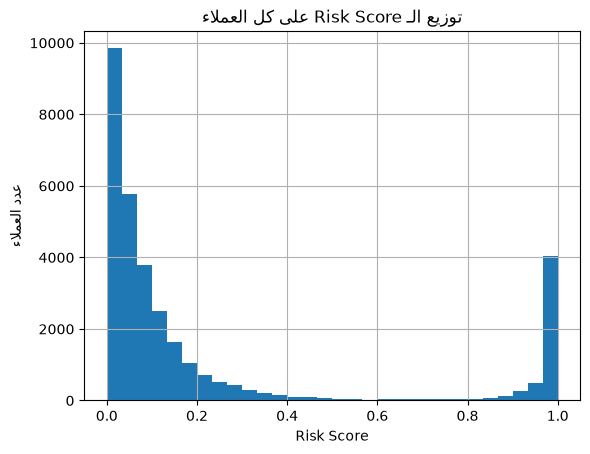

In [14]:
df['risk_score'].hist(bins=30)
plt.title('توزيع الـ Risk Score على كل العملاء')
plt.xlabel('Risk Score')
plt.ylabel('عدد العملاء')
plt.show()

In [15]:
def get_risk_tier(score):
    if score < 0.3:
        return 'Low'
    elif score < 0.7:
        return 'Medium'
    else:
        return 'High'

df['risk_tier'] = df['risk_score'].apply(get_risk_tier)

print(df['risk_tier'].value_counts())
print(df['risk_tier'].value_counts(normalize=True) * 100)

risk_tier
Low       26275
High       5184
Medium     1115
Name: count, dtype: int64
risk_tier
Low       80.662492
High      15.914533
Medium     3.422975
Name: proportion, dtype: float64


In [16]:
df_readable = pd.read_csv('../preprocessing/credit_risk_clean.csv')  # ← ده الملف النضيف الغير مشفّر (فيه RENT, MEDICAL... كلام مقروء)


In [17]:
df_readable['risk_score'] = df['risk_score']   # ← بنضيف عليه النتايج
df_readable['risk_tier'] = df['risk_tier']

df_readable.to_csv('credit_risk_scored.csv', index=False)

In [18]:
df_readable

,customer_id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,risk_score,risk_tier
0,CUST_00001,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,0.030139,Low
1,CUST_00002,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,0.973288,High
2,CUST_00003,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,0.996863,High
3,CUST_00004,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,0.995281,High
4,CUST_00005,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,0.998540,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32569,CUST_32570,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30,0.099150,Low
32570,CUST_32571,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19,0.010266,Low
32571,CUST_32572,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28,0.982723,High
32572,CUST_32573,56,140250,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26,0.068775,Low


c:\Users\hp\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


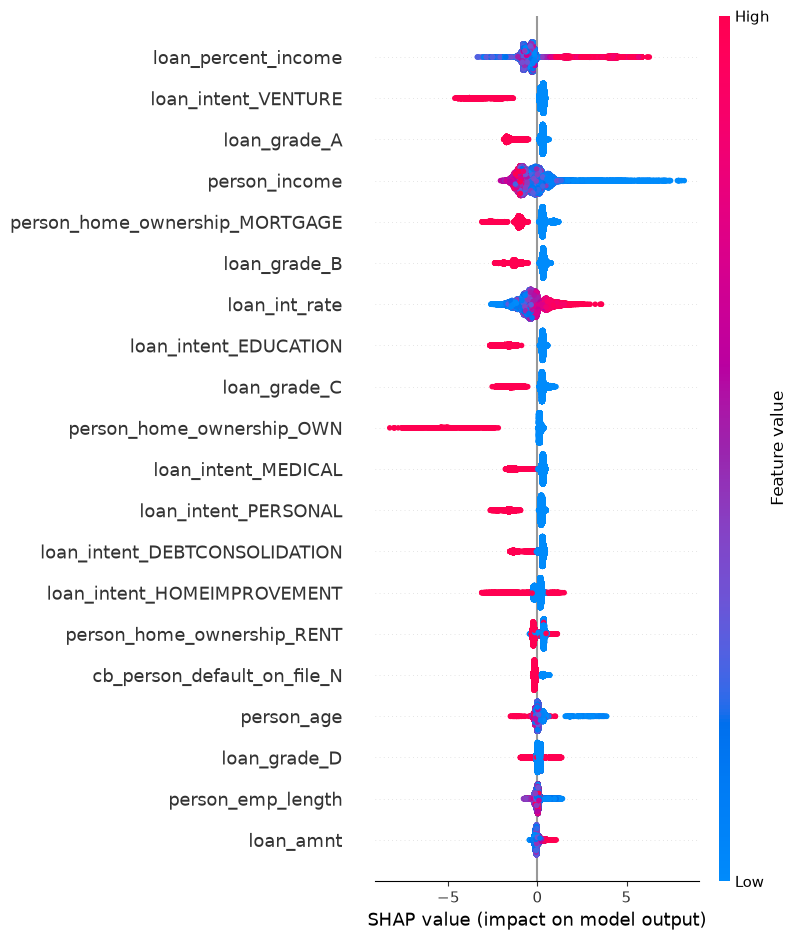

In [20]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# شوف أهم الفيتشرز بشكل عام على كل الداتا
shap.summary_plot(shap_values, X)